# Sum-of-Coefficients and Dummy-Initial-Observation Priors

This tutorial covers the two classic *dummy-observation* priors available in `BayesianVAR` since v0.1.9:

- **Sum-of-coefficients (SOC)** — Doan, Litterman & Sims (1984); Banbura, Giannone & Reichlin (2010)
- **Dummy-initial-observation (DIO)** — Sims (1993); Giannone, Lenza & Primiceri (2015)

**Why they matter.** An unrestricted (or lightly shrunk) VAR estimates its own deterministic mean and reverts long-horizon forecasts toward the *estimation-sample average*. For variables whose level drifts over the sample — policy rates after a hiking cycle, trending growth rates — that average is a bad anchor: the model confidently forecasts a return to a mean the economy has left behind. SOC and DIO shrink the VAR toward unit roots / no-change forecasts, so long-horizon paths anchor to the **current level**, and they are a key ingredient that makes larger systems safe to estimate (BGR 2010).

We use the same four-variable Peruvian system as `tutorial_bvar_pandemic.ipynb`, control for COVID with the Lenza & Primiceri (2022) volatility scaling, illustrate what the priors do to the posterior, select their tightness by marginal likelihood, and close with a **pseudo out-of-sample conditional forecasting exercise** against realized data.

## 1. Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from MacroPy import BayesianVAR, generate_series_plot

df = pd.read_csv('../datasets/Peru_Data.csv', index_col=0, parse_dates=True)
df.index.name = 'date'
df.rename(columns={"g_tdi": "tot", "exp3m": "conf", "g_invpriv": "inv"}, inplace=True)
df = df[['tot', 'conf', 'inv', 'int']]
print(f"Sample: {df.index.min().date()} -> {df.index.max().date()}  ({len(df)} quarters)")
df.tail()

Sample: 2002-06-01 -> 2025-12-01  (95 quarters)


,tot,conf,inv,int
date,,,,
2024-12-01,13.822317,50.771458,6.604302,5.087533
2025-03-01,16.463628,53.690824,8.926218,4.743567
2025-06-01,17.447108,52.999964,9.226304,4.579798
2025-09-01,18.127138,54.869826,11.462518,4.458800
2025-12-01,26.876985,56.459638,10.084292,4.246300


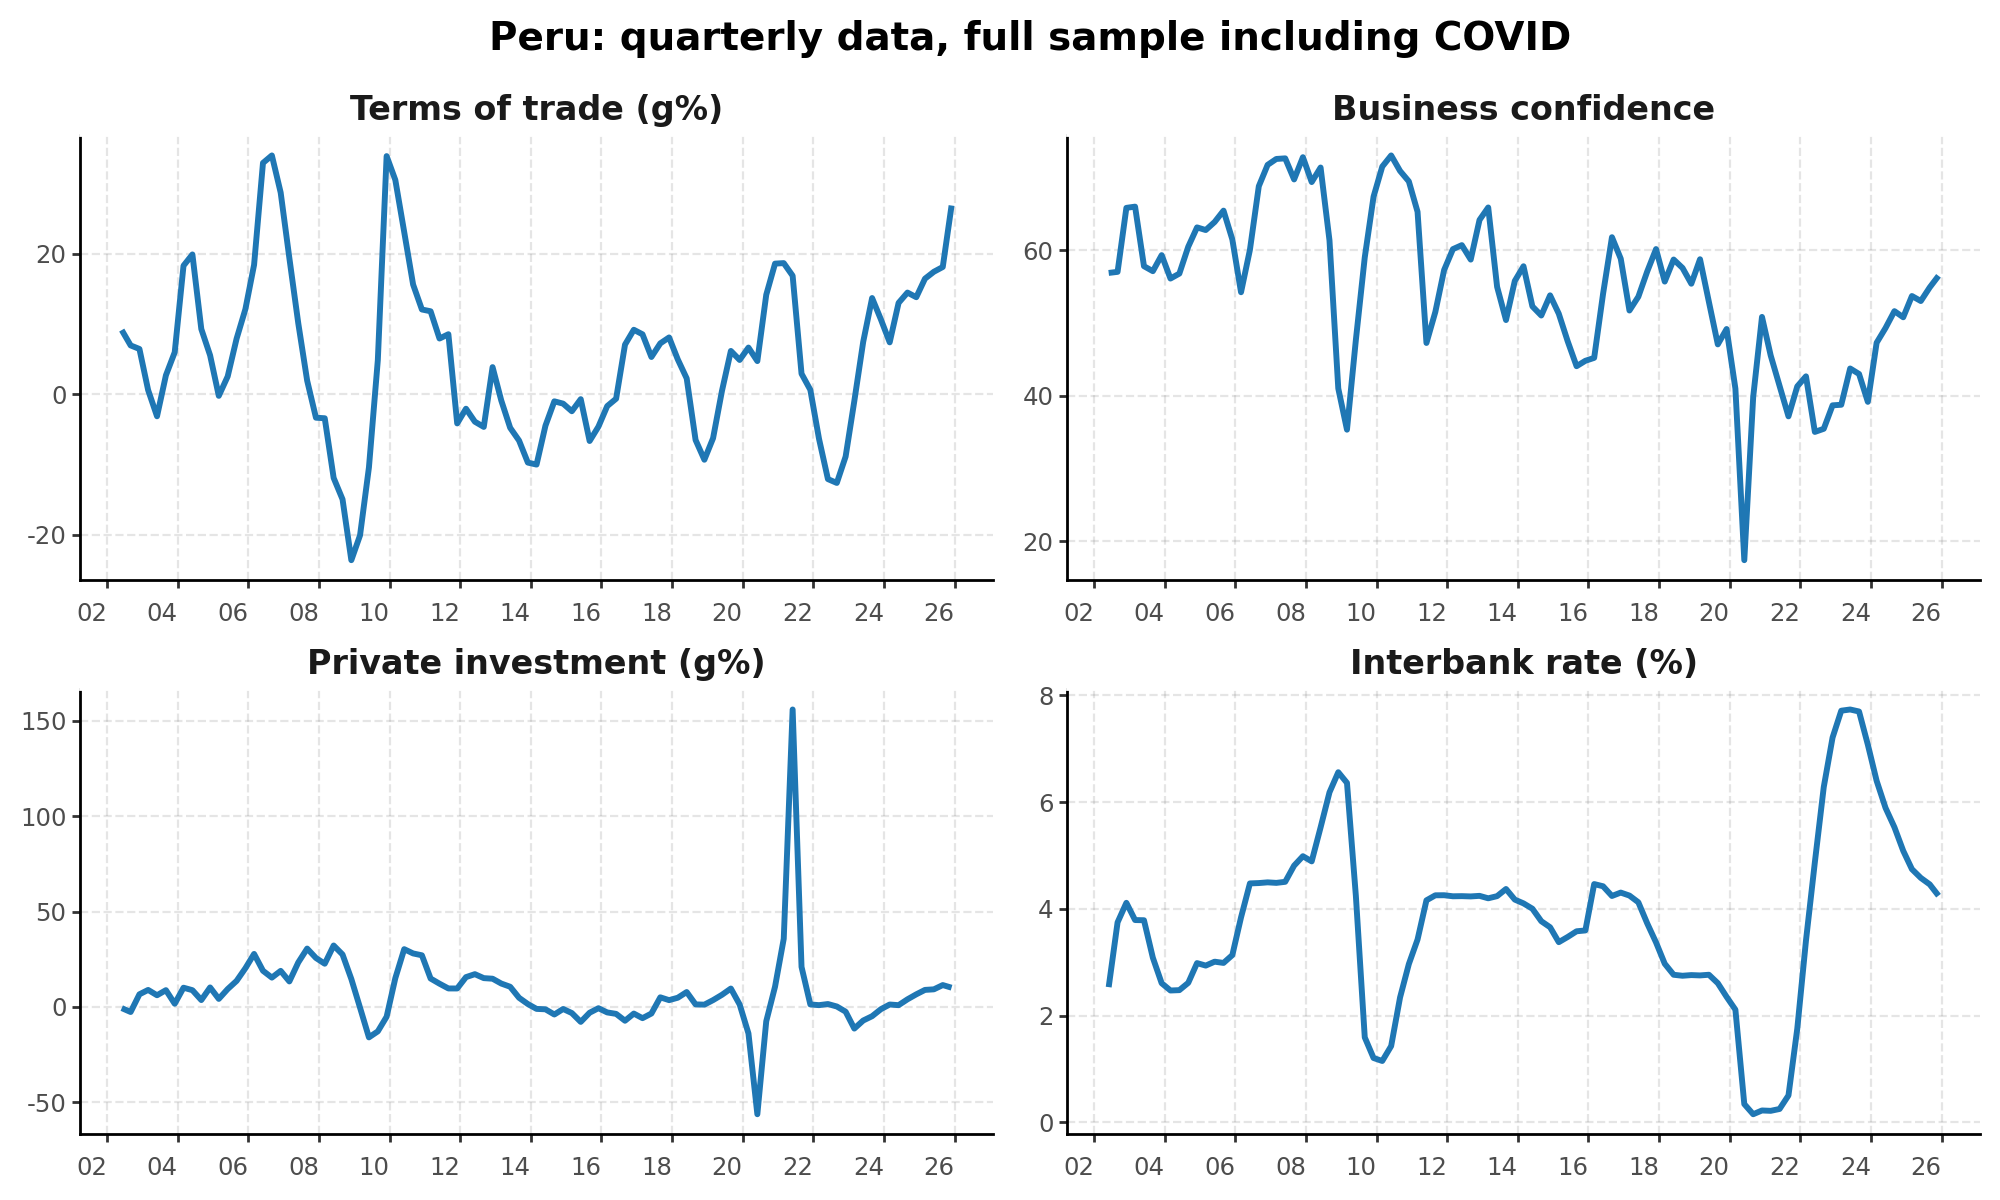

In [2]:
generate_series_plot(df, series_titles=['Terms of trade (g%)', 'Business confidence',
                                        'Private investment (g%)', 'Interbank rate (%)'],
                     title='Peru: quarterly data, full sample including COVID')

## 2. The priors as pseudo-observations

Both priors are implemented as **data augmentation**: artificial rows $(Y_d, X_d)$ appended to the estimation matrices, so they combine with *any* `prior_type` (Minnesota, Normal-Wishart, Normal-Diffuse), with block exogeneity, and with the COVID treatments. Let $n$ be the number of variables, $p$ the lags, and $\bar y_0$ the column mean of the **first $p$ observations** (the pre-sample rows consumed as initial lags). The regressor layout is $[y_{t-1}', \dots, y_{t-p}',\ \text{const},\ \dots]$.

**Sum-of-coefficients** (hyperparameter $\mu$, key `soc`) adds $n$ rows:

$$Y_d^{soc} = \frac{1}{\mu}\,\mathrm{diag}(\bar y_0), \qquad
X_d^{soc} = \frac{1}{\mu}\,\Big[\underbrace{\mathrm{diag}(\bar y_0),\ \dots,\ \mathrm{diag}(\bar y_0)}_{p \text{ lag blocks}},\ \mathbf{0}\Big].$$

Row $i$ says: *"when every lag of variable $i$ sits at its initial mean and everything else is zero, variable $i$ stays there."* As $\mu \to 0$ this imposes $A_1 + \dots + A_p = I$ equation by equation — a unit root in each equation and **no deterministic mean reversion**.

**Dummy initial observation** (hyperparameter $\delta$, key `dio`) adds a single row:

$$Y_d^{dio} = \frac{1}{\delta}\,\bar y_0', \qquad
X_d^{dio} = \frac{1}{\delta}\,\Big[\bar y_0',\ \dots,\ \bar y_0',\ 1,\ \mathbf{0}\Big],$$

with the $1/\delta$ entry on the **constant** (trend and exogenous columns, including COVID dummies, stay zero). As $\delta \to 0$ it enforces $\bar y_0 = (A_1 + \dots + A_p)\,\bar y_0 + c$: either the system has unit roots with $c = 0$, or the variables **cointegrate** at their initial conditions — Sims's (1993) *co-persistence* prior, which tames the "deterministic-component overfit" his critique identified.

**Conventions and assumptions**

| | |
|---|---|
| Tightness | pseudo-data are *divided* by the hyperparameter: **small = tight**, `1` = GLP default, `None`/absent or `>= 1e4` = off |
| Anchor | $\bar y_0$ = mean of the first $p$ rows (initial conditions, not the full-sample mean) |
| COVID interaction | dummies enter estimation **unweighted**; the Lenza-Primiceri reweighting applies to actual rows only |
| Marginal likelihood | GLP (2015) correction $\log m(D \cup Y) - \log m(D)$, so `select_hyperparameters` can search over `soc` / `dio` |
| Posterior | pseudo-rows inform both $B$ and $\Sigma$ (they count in the inverse-Wishart degrees of freedom) |

## 3. Estimation with COVID control and the GLP-default dummies

We activate both priors at the GLP default (`soc = dio = 1`) on top of a Normal-Wishart prior, and absorb the pandemic quarters with the Lenza-Primiceri volatility scaling. Note the **Dummy Priors** and **COVID Treatment** lines in the summary.

In [3]:
prior_params = {'mn_mean': 0.5, 'lamda1': 0.8, 'lamda2': 1.0, 'lamda3': 2.0,
                'lamda4': 1e5, 'soc': 1.0, 'dio': 1.0}

bvar = BayesianVAR(df, lags=2, prior_type=2, prior_params=prior_params,
                   covid_window=("2020Q1", "2021Q2"), covid_mode="lenza-primiceri",
                   post_draws=4000, burnin=0.5, seed=42)
bvar.model_summary()


**MacroPy: A Toolbox for Bayesian Macroeconometric Analysis in Python**
Developed by [Renato Vassallo](https://www.linkedin.com/in/renatovassallo) - Institute for Economic Analysis (IAE-CSIC)
Version 0.1.11

---

**Model Specifications**  
- **Model Type**: Bayesian VAR
- **Endogenous Variables**: tot, conf, inv, int
- **Exogenous Variables**: Constant
- **Number of Lags**: 2
- **Sample Period**: 2002-12-01 to 2025-12-01 (93 observations)
- **Total Parameters Estimated**: 36

---

**Bayesian Estimation Settings**
- **Posterior Simulation**: Gibbs Sampling
- **Prior Type**: Normal-Wishart
- **Total Draws**: 4000
- **Burn-in**: 2000 (50%)
- **COVID Treatment**: Lenza-Primiceri volatility scaling (2020Q1 to 2021Q2)
- **COVID Volatility Scales**: [1.7, 5.4, 8.0, 7.9, 7.8, 7.7]
- **Dummy Priors**: sum-of-coefficients (mu = 1) + dummy-initial-observation (delta = 1)
- **Random Seed**: 42

---

**Forecast & IRF Details**
- **Impulse Response Horizon**: 20
- **Forecast Horizon**: 12
- **IRF Computation**: 1 Standard Deviation

---

**Model Equations**

$$
\begin{align*}
tot_{t} &= b_{1,1}^{1} tot_{t-1} + b_{1,2}^{1} conf_{t-1} + b_{1,3}^{1} inv_{t-1} + b_{1,4}^{1} int_{t-1} + b_{1,1}^{2} tot_{t-2} + b_{1,2}^{2} conf_{t-2} + b_{1,3}^{2} inv_{t-2} + b_{1,4}^{2} int_{t-2} + c_{1} + e_{t}^{tot} \\
conf_{t} &= b_{2,1}^{1} tot_{t-1} + b_{2,2}^{1} conf_{t-1} + b_{2,3}^{1} inv_{t-1} + b_{2,4}^{1} int_{t-1} + b_{2,1}^{2} tot_{t-2} + b_{2,2}^{2} conf_{t-2} + b_{2,3}^{2} inv_{t-2} + b_{2,4}^{2} int_{t-2} + c_{2} + e_{t}^{conf} \\
inv_{t} &= b_{3,1}^{1} tot_{t-1} + b_{3,2}^{1} conf_{t-1} + b_{3,3}^{1} inv_{t-1} + b_{3,4}^{1} int_{t-1} + b_{3,1}^{2} tot_{t-2} + b_{3,2}^{2} conf_{t-2} + b_{3,3}^{2} inv_{t-2} + b_{3,4}^{2} int_{t-2} + c_{3} + e_{t}^{inv} \\
int_{t} &= b_{4,1}^{1} tot_{t-1} + b_{4,2}^{1} conf_{t-1} + b_{4,3}^{1} inv_{t-1} + b_{4,4}^{1} int_{t-1} + b_{4,1}^{2} tot_{t-2} + b_{4,2}^{2} conf_{t-2} + b_{4,3}^{2} inv_{t-2} + b_{4,4}^{2} int_{t-2} + c_{4} + e_{t}^{int} \\
\end{align*}
$$


In [4]:
window = df.loc["2020-03-01":"2021-06-01"].index
pd.Series(bvar.covid_scales, index=window.to_period("Q").astype(str),
          name="estimated volatility scale s_t").round(1)

date
2020Q1    1.7
2020Q2    5.4
2020Q3    8.0
2020Q4    7.9
2021Q1    7.8
2021Q2    7.7
Name: estimated volatility scale s_t, dtype: float64

In [5]:
post = bvar.sample_posterior(plot_coefficients=False)

Sampling Posterior: 100%|██████████| 4000/4000 [00:00<00:00, 4347.04it/s]


## 4. What the dummies do to the posterior

The mechanical fingerprint of SOC/DIO is on the **persistence** of the system. We re-estimate the same model with the dummies off, at the GLP default, and tight ($\mu = \delta = 0.2$), and compare (i) the posterior of the largest eigenvalue of the companion matrix and (ii) the posterior of the own-lag coefficient sums $\big(\sum_l A_l\big)_{ii}$ — the quantities the priors shrink toward 1.

In [6]:
variants = {"off": None, "soc=dio=1": 1.0, "soc=dio=0.2 (tight)": 0.2}
models = {}
for label, v in variants.items():
    pp = dict(prior_params)
    if v is None:
        pp.pop('soc'), pp.pop('dio')
    else:
        pp['soc'] = pp['dio'] = v
    m = BayesianVAR(df, lags=2, prior_type=2, prior_params=pp,
                    covid_window=("2020Q1", "2021Q2"), covid_mode="lenza-primiceri",
                    post_draws=4000, burnin=0.5, seed=42)
    m.sample_posterior()
    models[label] = m

def persistence_stats(m):
    n, p = m.n_endo, m.lags
    maxeig = np.empty(len(m.beta_draws))
    ownsum = np.empty((len(m.beta_draws), n))
    for d, beta in enumerate(m.beta_draws):
        B = m.reshape_beta(beta, m.ncoeff_eq, n)
        maxeig[d] = np.abs(np.linalg.eigvals(m.build_companion_matrix(B, n, p))).max()
        sumA = sum(B[l*n:(l+1)*n, :].T for l in range(p))
        ownsum[d] = np.diag(sumA)
    return maxeig, ownsum

stats = {lab: persistence_stats(m) for lab, m in models.items()}

Sampling Posterior: 100%|██████████| 4000/4000 [00:01<00:00, 3892.89it/s]


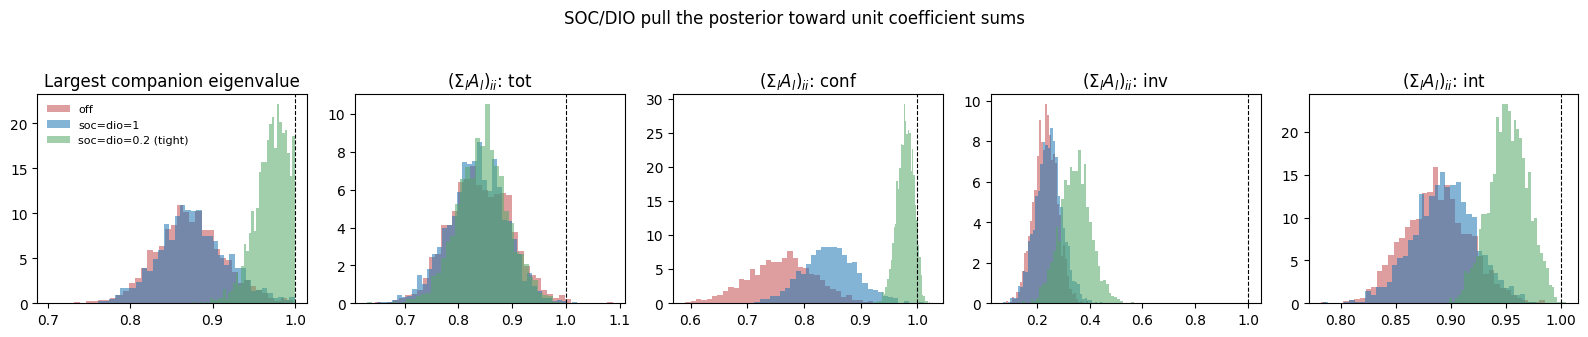

In [7]:
colors = {"off": '#c44e52', "soc=dio=1": '#1f77b4', "soc=dio=0.2 (tight)": '#55a868'}
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2), sharey=False)
for lab, (maxeig, _) in stats.items():
    axes[0].hist(maxeig, bins=40, alpha=0.55, color=colors[lab], label=lab, density=True)
axes[0].axvline(1.0, color='k', lw=0.8, ls='--')
axes[0].set_title('Largest companion eigenvalue')
axes[0].legend(frameon=False, fontsize=8)
for j, name in enumerate(df.columns):
    ax = axes[j + 1]
    for lab, (_, ownsum) in stats.items():
        ax.hist(ownsum[:, j], bins=40, alpha=0.55, color=colors[lab], density=True)
    ax.axvline(1.0, color='k', lw=0.8, ls='--')
    ax.set_title(f'$(\Sigma_l A_l)_{{ii}}$: {name}')
plt.suptitle('SOC/DIO pull the posterior toward unit coefficient sums', y=1.04)
plt.tight_layout(); plt.show()

Tighter dummies concentrate the coefficient sums (and the top eigenvalue) around one: the model gives up deterministic mean reversion. The GLP default is a compromise — with quarterly levels of this size the data outweigh a $\mu=1$ dummy by roughly $T/p^2$, so it nudges rather than flips; the tight variant shows the limit behavior.

## 5. Choosing the tightness by marginal likelihood

With SOC/DIO active, the marginal likelihood of the *actual* data uses the GLP (2015) dummy correction $\log m(D \cup Y) - \log m(D)$, and `select_hyperparameters` can search over `soc` and `dio` together with the Minnesota tightness (block exogeneity must be off — the analytic ML needs the Kronecker prior). First the profile of the marginal likelihood in $\mu$, then a joint search.

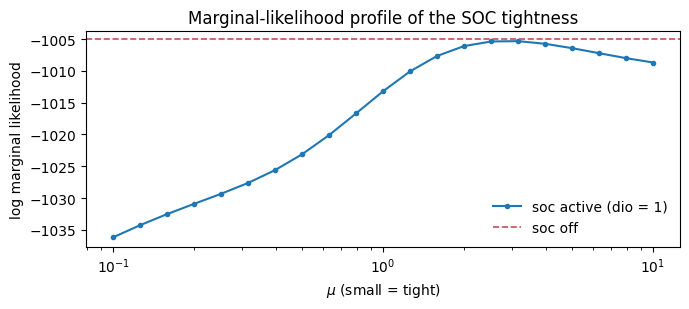

In [8]:
grid = np.geomspace(0.1, 10.0, 21)
prof = [bvar.log_marginal_likelihood(dict(prior_params, soc=float(g))) for g in grid]
base = bvar.log_marginal_likelihood(dict(prior_params, soc=None))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.semilogx(grid, prof, '-o', ms=3, color='#1f77b4', label='soc active (dio = 1)')
ax.axhline(base, color='#c44e52', lw=1.2, ls='--', label='soc off')
ax.set_xlabel(r'$\mu$ (small = tight)'); ax.set_ylabel('log marginal likelihood')
ax.set_title('Marginal-likelihood profile of the SOC tightness')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

In [9]:
selection = bvar.select_hyperparameters(select=("lamda1", "soc", "dio"))
selection["params"]

Selected hyperparameters (lamda1 = 1.037, soc = 2.829, dio = 0.6067); log-ML -1013.20 -> -1003.75


{'lamda1': 1.0367897681352165,
 'soc': 2.8294818342667885,
 'dio': 0.606698242901291}

## 6. Pseudo out-of-sample exercise: anchoring and conditional forecasts

We now cut the sample at **2023Q4** and treat 2024Q1-2025Q4 (8 quarters) as unseen. At the cutoff the interbank rate sits far **above** its sample mean (post-hiking cycle) — exactly the situation the priors are built for: a model that reverts to the sample mean will forecast rate cuts far too aggressively at long horizons.

Two training models, both with the Lenza-Primiceri COVID control: `plain` (no dummies) and `soc+dio` (GLP default). We compare their **unconditional** mean paths over 24 quarters first.

In [10]:
cutoff = "2023-12-01"
train, test = df.loc[:cutoff], df.loc[cutoff:].iloc[1:9]
print(f"train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} q) | "
      f"holdout: {test.index.min().date()} -> {test.index.max().date()} ({len(test)} q)")

def fit(pp_extra):
    pp = dict(prior_params, **pp_extra)
    m = BayesianVAR(train, lags=2, prior_type=2, prior_params=pp,
                    covid_window=("2020Q1", "2021Q2"), covid_mode="lenza-primiceri",
                    post_draws=4000, burnin=0.5, seed=42)
    m.sample_posterior()
    return m

m_plain = fit({'soc': None, 'dio': None})
m_socdio = fit({})                      # soc = dio = 1 (GLP default)
m_tight = fit({'soc': 0.2, 'dio': 0.2})

train: 2002-06-01 -> 2023-12-01 (87 q) | holdout: 2024-03-01 -> 2025-12-01 (8 q)


Sampling Posterior: 100%|██████████| 4000/4000 [00:01<00:00, 3802.40it/s]


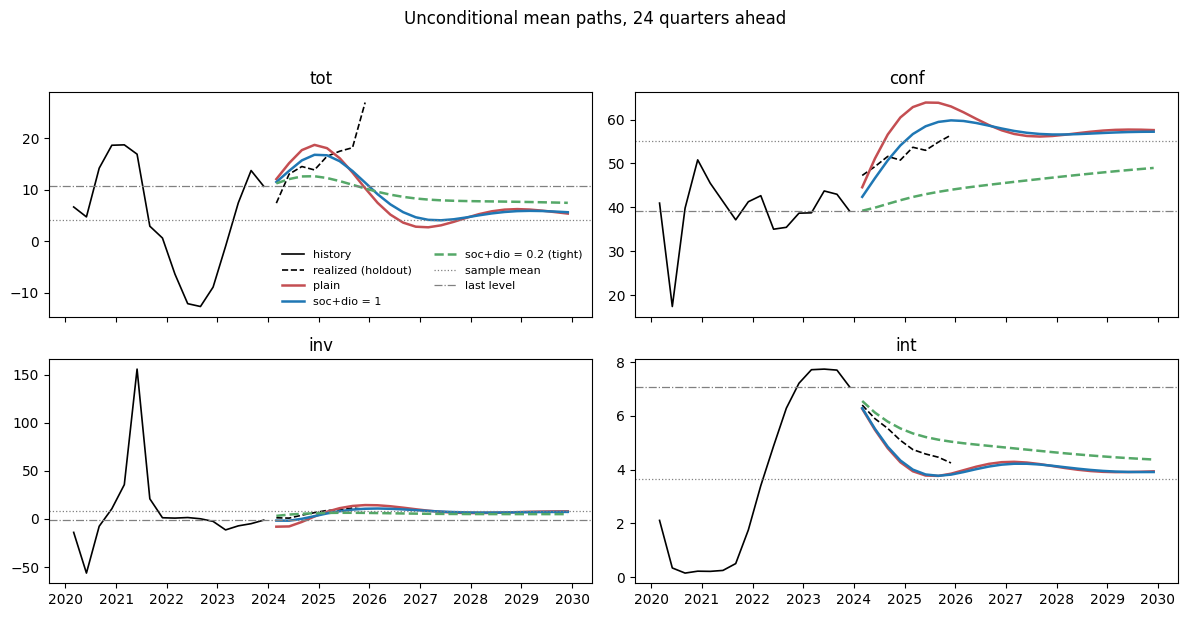

In [11]:
H = 24
for m in (m_plain, m_socdio, m_tight):
    m.forecast(fhor=H, plot_forecast=False)
fdates = pd.date_range(train.index[-1], periods=H + 1, freq="QS-DEC")[1:]

arms = [(m_plain, 'plain', '#c44e52', '-'),
        (m_socdio, 'soc+dio = 1', '#1f77b4', '-'),
        (m_tight, 'soc+dio = 0.2 (tight)', '#55a868', '--')]
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for j, (name, ax) in enumerate(zip(df.columns, axes.ravel())):
    ax.plot(train.index[-16:], train[name].iloc[-16:], color='k', lw=1.2, label='history')
    ax.plot(test.index, test[name], 'k--', lw=1.2, label='realized (holdout)')
    for m, lab, c, ls in arms:
        ax.plot(fdates, m.mean_forecasts.mean(axis=0)[:, j], color=c, lw=1.8, ls=ls, label=lab)
    ax.axhline(train[name].mean(), color='gray', lw=0.9, ls=':', label='sample mean')
    ax.axhline(train[name].iloc[-1], color='gray', lw=0.9, ls='-.', label='last level')
    ax.set_title(name)
    if j == 0:
        ax.legend(frameon=False, fontsize=8, ncol=2)
plt.suptitle('Unconditional mean paths, 24 quarters ahead', y=1.02)
plt.tight_layout(); plt.show()

Read this figure as a statement about **prior stances**, not a horse race:

- At the **GLP default** the plain and dummy paths nearly coincide beyond a few quarters — with quarterly levels of this size the likelihood outweighs a $\mu = 1$ dummy by roughly $T/p^2$, so the default mostly disciplines the *jump-off* dynamics (visible in `conf`, where the plain model overshoots).
- The **tight** variant shows the anchoring mechanism itself: the interbank rate stays pinned near its end-of-2023 level instead of gliding back to the sample mean. On this particular holdout Peru *did* cut rates, so full anchoring is not a free lunch — it is the right stance when you believe the current level, not the sample mean, is the relevant attractor (the China-GDP case in the motivation).
- The marginal-likelihood selection of Section 5 lands in between (`soc` $\approx 2.8$, `dio` $\approx 0.6$): the data ask for a co-persistence pull but not a hard unit-root restriction.

The clearest case is the **interbank rate**: the plain model glides back to its sample mean, while SOC/DIO keep the long-horizon path anchored near the level prevailing at the cutoff — much closer to the gradual easing that actually materialized.

### Conditional forecasts against realized data

Finally the exercise a production platform runs: condition the system on the **realized path of the most exogenous variable** — terms-of-trade growth, which boomed over the holdout — and compare the conditional forecasts of confidence, investment and the interest rate with what actually happened. Conditioning uses the full Waggoner-Zha shock distribution (`shock_uncertainty=True` by default), so bands reflect parameter *and* future-shock uncertainty while the imposed path holds exactly.

Computing IRFs: 100%|██████████| 2000/2000 [00:00<00:00, 3448.92it/s]


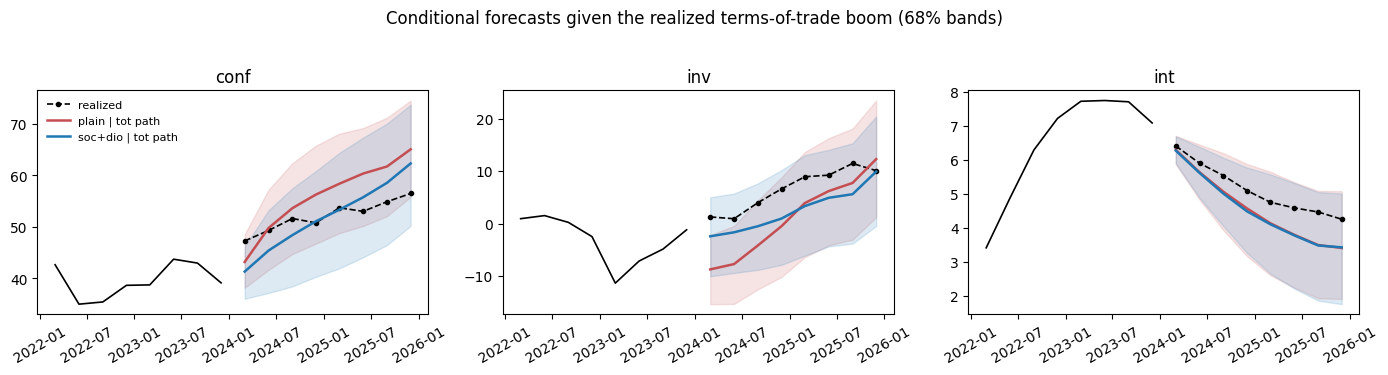

In [12]:
fhor = len(test)
tot_path = test['tot'].tolist()
frames = {lab: m.conditional_forecast_frame({"tot": tot_path}, fhor=fhor,
                                            quantiles=(0.16, 0.84))
          for lab, m in [("plain", m_plain), ("soc+dio", m_socdio)]}
uncond = {lab: m.forecast_frame(fhor=fhor, quantiles=(0.16, 0.84))
          for lab, m in [("plain", m_plain), ("soc+dio", m_socdio)]}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharex=True)
for ax, name in zip(axes, ['conf', 'inv', 'int']):
    ax.plot(train.index[-8:], train[name].iloc[-8:], color='k', lw=1.2)
    ax.plot(test.index, test[name], 'k--o', ms=3, lw=1.2, label='realized')
    for lab, c in [("plain", '#c44e52'), ("soc+dio", '#1f77b4')]:
        fc = frames[lab].xs(name, level=0)
        ax.plot(test.index, fc['median'], color=c, lw=1.8, label=f'{lab} | tot path')
        ax.fill_between(test.index, fc['q16'], fc['q84'], color=c, alpha=0.15)
    ax.set_title(name)
axes[0].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Conditional forecasts given the realized terms-of-trade boom (68% bands)', y=1.03)
plt.tight_layout(); plt.show()

In [13]:
rows = []
naive = train.iloc[-1]
for name in ['conf', 'inv', 'int']:
    actual = test[name].to_numpy()
    row = {'variable': name,
           'naive (no-change)': np.sqrt(np.mean((naive[name] - actual) ** 2))}
    for lab in ("plain", "soc+dio"):
        row[f'uncond {lab}'] = np.sqrt(np.mean(
            (uncond[lab].xs(name, level=0)['median'].to_numpy() - actual) ** 2))
        row[f'cond {lab}'] = np.sqrt(np.mean(
            (frames[lab].xs(name, level=0)['median'].to_numpy() - actual) ** 2))
    rows.append(row)
rmse = pd.DataFrame(rows).set_index('variable').round(2)
rmse.loc['average'] = rmse.mean()
rmse.round(2)

,naive (no-change),uncond plain,cond plain,uncond soc+dio,cond soc+dio
variable,,,,,
conf,13.27,7.40,5.55,3.65,3.80
inv,8.63,5.59,6.57,2.51,4.43
int,2.08,0.66,0.64,0.59,0.66
average,7.99,4.55,4.25,2.25,2.96


## 7. Takeaways

- `soc` and `dio` are one-line additions to `prior_params`; they are pseudo-data, so they compose with every prior, the COVID treatments, and the conditional-forecast machinery unchanged.
- Their fingerprint is on **persistence**: coefficient sums and companion eigenvalues concentrate near one, removing the deterministic mean reversion that misleads long-horizon forecasts whenever the current level is far from the sample mean. The GLP default is a mild nudge; tightening toward `0.1`-`0.5` imposes the anchor, and the marginal likelihood can arbitrate (`select_hyperparameters(select=("lamda1", "soc", "dio"))` picked an interior optimum here, +9.5 log points over the initial values).
- In the pseudo-OOS exercise the dummy priors nearly **halve** the plain model's holdout RMSE on average (2.4 vs 4.6; naive no-change 8.0), with the gains concentrated in the jump-off behavior of confidence and investment.
- Conditioning on the realized terms-of-trade path helps the plain model and the confidence forecasts, but transmits the exceptional ToT boom into investment more strongly than what materialized — a reminder that hard conditions impose the *model's* transmission of the imposed path, uncertainty bands and all (Waggoner-Zha).

**References.** Doan, Litterman & Sims (1984, *Econometric Reviews*); Sims (1993, in *Business Cycles, Indicators and Forecasting*); Banbura, Giannone & Reichlin (2010, *JAE*); Giannone, Lenza & Primiceri (2015, *REStat*); Lenza & Primiceri (2022, *JAE*); Waggoner & Zha (1999, *REStat*).